## Note

This notebook has been tested and validated on UCL’s Unified AI platform, a high-performance AI infrastructure for research at UCL, using a namespace configured with 5 CPUs and 64 GB RAM.

The notebook should also run in any standard environment, provided that the required dependencies are installed.

If you need support with AI platforms, with or without GPUs, Carpentries training, or any other computing-related resources, please do not hesitate to contact the ARC Collaborations team at ARC.Collaborations@ucl.ac.uk.

In [1]:
import tensorflow
import seaborn
import sklearn
import keras_tuner
import tensorboard
import matplotlib.pyplot as plt
import time
import pathlib
import numpy as np

print(tensorflow.__version__)
print(seaborn.__version__)
print(sklearn.__version__)
print(keras_tuner.__version__)
print(tensorboard.__version__)

I0000 00:00:1779878747.092707 1290005 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0
0.13.2
1.8.0
1.4.8
2.20.0


In [2]:
!mkdir -p /home/jovyan/data/dataset_dollarstreet

In [3]:
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/test_images.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/test_labels.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/train_images.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/train_labels.npy

File ‘/home/jovyan/data/dataset_dollarstreet/test_images.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/test_labels.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/train_images.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/train_labels.npy’ already there; not retrieving.



In [4]:
DATA_FOLDER = pathlib.Path('/home/jovyan/data/dataset_dollarstreet') # change to location where you stored the data
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

In [5]:
# Label -> Category mapping
label_to_category = {
    0: "day bed",
    1: "dishrag",
    2: "plate",
    3: "running shoe",
    4: "soap dispenser",
    5: "street sign",
    6: "table lamp",
    7: "tile roof",
    8: "toilet seat",    
    9: "washing machine"
}

Text(0.5, 1.0, 'Training Class Distribution')

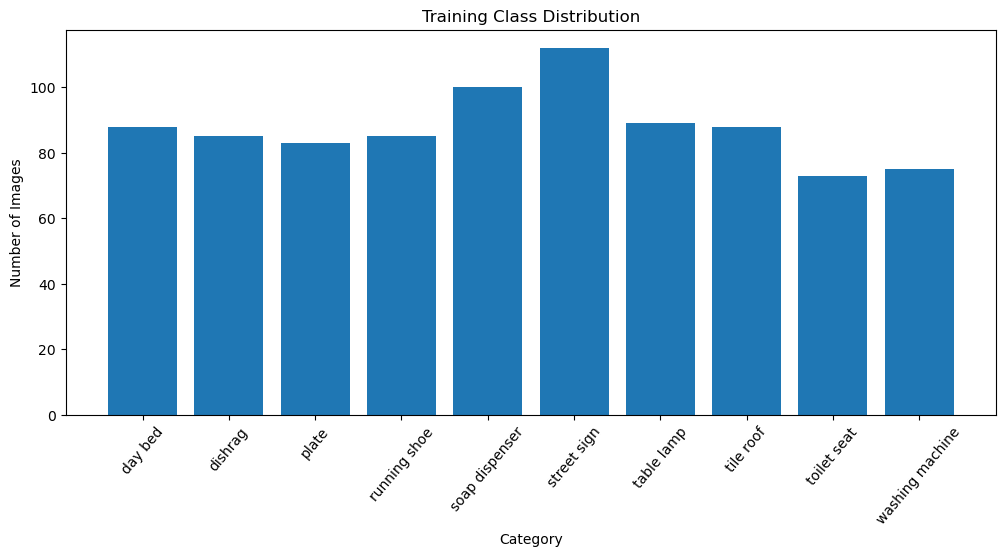

In [6]:
# Plot class distribution

unique_classes, counts = np.unique(train_labels, return_counts=True)
# Convert numeric labels to category names
class_names = [label_to_category[i] for i in unique_classes]

plt.figure(figsize=(12, 5))
plt.bar(class_names, counts)
plt.xticks(rotation=50)
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.title("Training Class Distribution")  

In [7]:
sample_number=100
label_sample = label_to_category[train_labels[sample_number]]
label_sample

'running shoe'

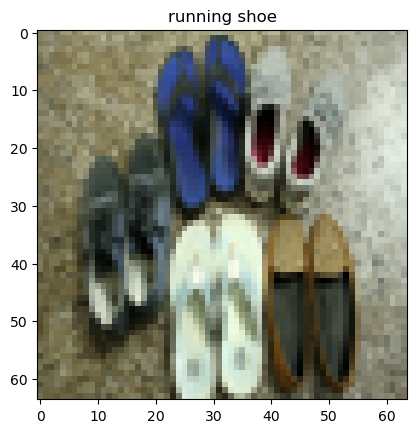

In [8]:
import matplotlib.pyplot as plt
plt.imshow(train_images[sample_number])
plt.title(f"{label_sample}")
plt.show()
 

In [9]:
train_images.shape

(878, 64, 64, 3)

In [10]:
train_images.min(), train_images.max()

(0, 255)

In [11]:
train_labels.shape

(878,)

In [12]:
train_labels.min(), train_labels.max()

(0, 9)

In [13]:
# The training set consists of 878 images of 64x64 pixels and 3 channels (RGB values). 
# The RGB values are between 0 and 255. For input of neural networks, it is better to have small input values. So we normalize our data between 0 and 1:
train_images = train_images / 255.0
val_images = val_images / 255.0

In [14]:
width, height = (64, 64)
n_hidden_neurons = 100
n_bias = 100
n_input_items = width * height * 3 #12288
n_parameters = (n_input_items * n_hidden_neurons) + n_bias
n_parameters

1228900

In [15]:
from tensorflow import keras
keras.utils.set_random_seed(2)

inputs = keras.Input(shape=(n_input_items,))
outputs = keras.layers.Dense(100)(inputs)
model = keras.models.Model(inputs=inputs, outputs=outputs)
model.summary()

E0000 00:00:1779878752.663850 1290005 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,228,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,228,900 (4.69 MB)

 Trainable params: 1,228,900 (4.69 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
inputs = keras.Input(shape=train_images.shape[1:])
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
x = keras.layers.Flatten()(x)
outputs = keras.layers.Dense(10)(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="dollar_street_model_small")

model.summary()

Model: "dollar_street_model_small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 180000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │     1,800,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,823,960 (6.96 MB)

 Trainable params: 1,823,960 (6.96 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
def create_nn(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x) # a new maxpooling layer
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x) # a new maxpooling layer (same as maxpool)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x) # a new Dense layer
    outputs = keras.layers.Dense(10)(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="dollar_street_model")
    return model

model = create_nn(input_shape=train_images.shape[1:])
model.summary()

Model: "dollar_street_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │       490,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 514,510 (1.96 MB)

 Trainable params: 514,510 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
def compile_model(model):
    model.compile(optimizer='adam',
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
compile_model(model)

In [19]:
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(val_images, val_labels))

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.1082 - loss: 2.3092 - val_accuracy: 0.1297 - val_loss: 2.2813
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.1731 - loss: 2.2539 - val_accuracy: 0.2082 - val_loss: 2.2147
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.2597 - loss: 2.0984 - val_accuracy: 0.3174 - val_loss: 2.0806
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.3610 - loss: 1.8474 - val_accuracy: 0.2662 - val_loss: 2.0662
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.4556 - loss: 1.5959 - val_accuracy: 0.2662 - val_loss: 2.1440


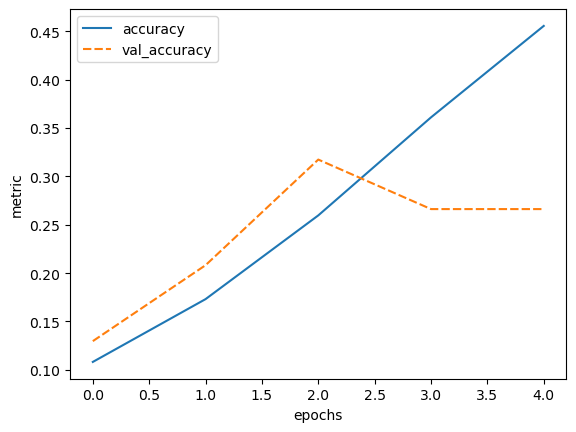

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")


plot_history(history, ['accuracy', 'val_accuracy'])

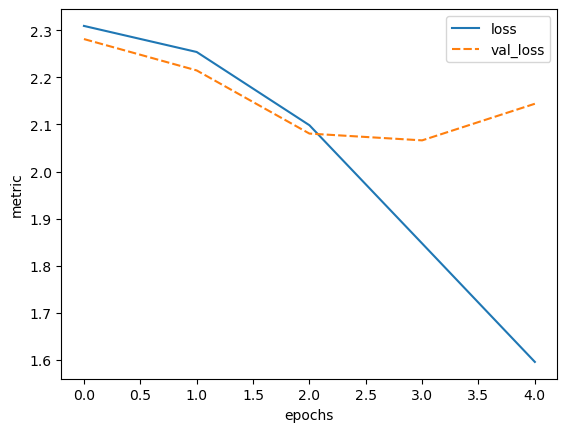

In [21]:
plot_history(history, ['loss', 'val_loss'])


In [22]:

#NOP
def create_dense_model():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Flatten()(inputs)
    x = keras.layers.Dense(50, activation='relu')(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    return keras.models.Model(inputs=inputs, outputs=outputs,
                              name='dense_model')

dense_model = create_dense_model()
dense_model.summary()

Model: "dense_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │       614,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,510 (2.36 MB)

 Trainable params: 617,510 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1196 - loss: 2.5585 - val_accuracy: 0.1604 - val_loss: 2.2559
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1390 - loss: 2.3124 - val_accuracy: 0.1297 - val_loss: 2.3061
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0934 - loss: 2.2959 - val_accuracy: 0.1092 - val_loss: 2.3024
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1173 - loss: 2.2871 - val_accuracy: 0.0990 - val_loss: 2.3015
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1276 - loss: 2.2751 - val_accuracy: 0.1468 - val_loss: 2.2943
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1367 - loss: 2.2718 - val_accuracy: 0.1160 - val_loss: 2.2941
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1333 - loss: 2.2744 - val_accuracy: 0.1672 - val_loss: 2.2825
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1788 - loss: 2.2240 - val_accuracy: 0.1433 - val_

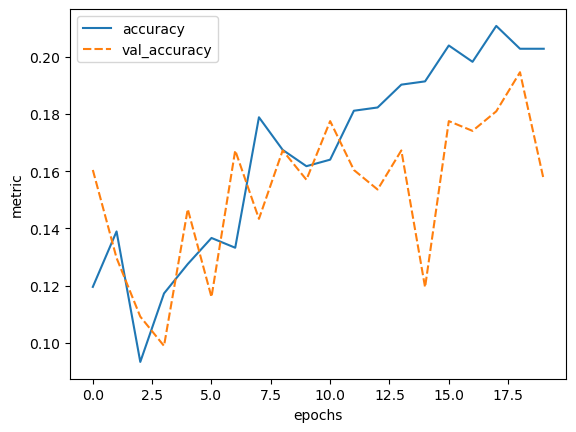

In [23]:

# Start the timer
start_time = time.time()

compile_model(dense_model)
history = dense_model.fit(train_images, 
                          train_labels, 
                          epochs=20,
                          validation_data=(val_images, val_labels))
plot_history(history, ['accuracy', 'val_accuracy'])

# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

In [24]:
inputs = keras.Input(shape=train_images.shape[1:])
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
x = keras.layers.MaxPooling2D((2, 2))(x)
# Add your extra layers here
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(50, activation='relu')(x)
outputs = keras.layers.Dense(10)(x)

In [25]:
def create_nn_extra_layer():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x) #
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x) # extra layer
    x = keras.layers.MaxPooling2D((2, 2))(x) # extra layer
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="dollar_street_model")
    return model

model = create_nn_extra_layer()

In [26]:
model.summary()


Model: "dollar_street_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │        90,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,060 (535.39 KB)

 Trainable params: 137,060 (535.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.1378 - loss: 2.3021 - val_accuracy: 0.1468 - val_loss: 2.2931
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.1572 - loss: 2.2814 - val_accuracy: 0.1570 - val_loss: 2.2869
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.1959 - loss: 2.2185 - val_accuracy: 0.1911 - val_loss: 2.1774
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.2494 - loss: 2.1204 - val_accuracy: 0.2150 - val_loss: 2.2026
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.3007 - loss: 1.9919 - val_accuracy: 0.2560 - val_loss: 2.1366

Training completed in 15.64 seconds or 0.26 minutes


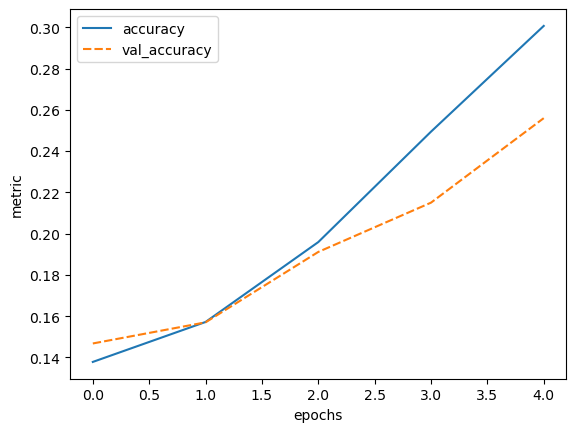

In [27]:
# Start the timer
start_time = time.time()

compile_model(model)
history = model.fit(train_images, 
                    train_labels, 
                    epochs=5,
                    validation_data=(val_images, val_labels))
plot_history(history, ['accuracy', 'val_accuracy'])


# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

In [28]:
def create_nn_with_dropout():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="dropout_model")
    return model

model_dropout = create_nn_with_dropout()
model_dropout.summary()

Model: "dropout_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 31, 31, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 50)             │        90,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,060 (535.39 KB)

 Trainable params: 137,060 (535.39 KB)

 Non-trainable params: 0 (0.00 B)

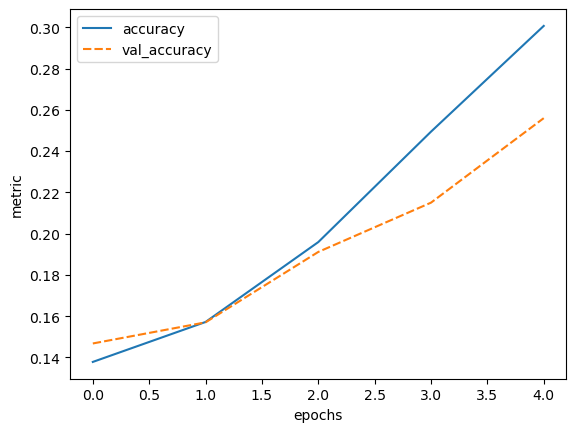

In [29]:
plot_history(history, ['accuracy', 'val_accuracy'])

In [30]:
def create_nn_with_dropout(dropout_rate):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(dropout_rate)(x)

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(dropout_rate)(x)

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="dropout_model")
    return model

early_stopper = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)


Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.1116 - loss: 2.3060 - val_accuracy: 0.1502 - val_loss: 2.2915
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.1424 - loss: 2.2869 - val_accuracy: 0.1604 - val_loss: 2.2732
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.1811 - loss: 2.2411 - val_accuracy: 0.1877 - val_loss: 2.2319
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.2210 - loss: 2.1609 - val_accuracy: 0.2253 - val_loss: 2.1948
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.2813 - loss: 2.0650 - val_accuracy: 0.2765 - val_loss: 2.1764
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.3064 - loss: 1.9697 - val_accuracy: 0.2594 - val_loss: 2.1724
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.3622 - loss: 1.8398 - val_accuracy: 0.2628 - val_loss: 2.1522
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.4134 - loss: 1.7230 - val_accuracy: 0.

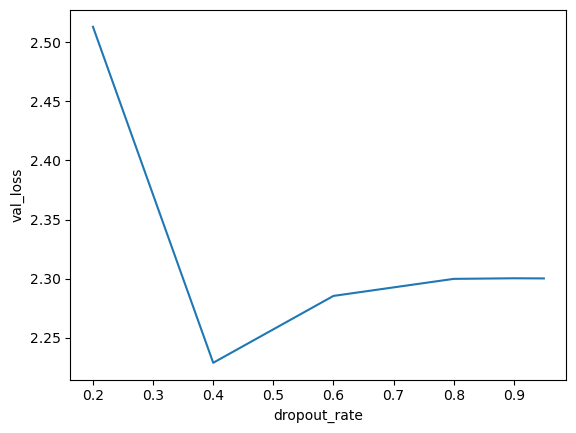

In [31]:
# Start the timer
start_time = time.time()

dropout_rates = [0.2, 0.4, 0.6, 0.8, 0.9, 0.95]
val_losses = []
for dropout_rate in dropout_rates:
    model_dropout = create_nn_with_dropout(dropout_rate)
    compile_model(model_dropout)
    model_dropout.fit(train_images, train_labels, epochs=30,
                      validation_data=(val_images, val_labels),
                      callbacks=[early_stopper]
                      )

    val_loss, val_acc = model_dropout.evaluate(val_images,  val_labels)
    val_losses.append(val_loss)

loss_df = pd.DataFrame({'dropout_rate': dropout_rates, 'val_loss': val_losses})


sns.lineplot(data=loss_df, x='dropout_rate', y='val_loss')



# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

In [32]:
def create_nn_with_hp(dropout_rate, n_layers):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = inputs
    for layer in range(n_layers):
        x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
        x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="cifar_model")
    return model

In [33]:
# Start the timer
start_time = time.time()



import keras_tuner

hp = keras_tuner.HyperParameters()

def build_model(hp):
    # Define values for hyperparameters to try out:
    n_layers = hp.Int("n_layers", min_value=1, max_value=2, step=1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.2, max_value=0.8, step=0.3)

    model = create_nn_with_hp(dropout_rate, n_layers)
    compile_model(model)
    return model

#tuner = keras_tuner.GridSearch(build_model, objective='val_loss')
tuner = keras_tuner.GridSearch(
    build_model,
    objective='val_loss',
    overwrite=True #Forces a fresh run
)

tuner.search(train_images, 
             train_labels, 
             epochs=20,
             validation_data=(val_images, val_labels))


# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

Trial 6 Complete [00h 00m 59s]
val_loss: 2.0840988159179688

Best val_loss So Far: 2.0838351249694824
Total elapsed time: 00h 06m 35s

Training completed in 394.99 seconds or 6.58 minutes


In [34]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0001 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.5
Score: 2.0838351249694824

Trial 0005 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.8
Score: 2.0840988159179688

Trial 0002 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.8
Score: 2.096228837966919

Trial 0003 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.2
Score: 2.104013442993164

Trial 0004 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.5
Score: 2.1218998432159424

Trial 0000 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.2
Score: 2.139098644256592


In [35]:
def create_nn_with_hp(activation_function, kernel_size):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = inputs
    for layer in range(3):
        x = keras.layers.Conv2D(50, (kernel_size, kernel_size), activation=activation_function)(x)
        x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation=activation_function)(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="cifar_model")
    return model

hp = keras_tuner.HyperParameters()

def build_model(hp):
    kernel_size = hp.Int("kernel_size", min_value=3, max_value=4, step=1)
    activation = hp.Choice("activation", ["relu", "tanh"])
    model = create_nn_with_hp(activation, kernel_size)
    compile_model(model)
    return model

tuner = keras_tuner.GridSearch(build_model, 
                               objective='val_loss', 
                               project_name='new_project')
tuner.search(train_images, 
             train_labels, 
             epochs=20,
             validation_data=(val_images, val_labels)
            )

Trial 4 Complete [00h 01m 15s]
val_loss: 2.053041458129883

Best val_loss So Far: 1.9949814081192017
Total elapsed time: 00h 04m 26s


In [36]:
tuner.results_summary()

Results summary
Results in ./new_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0001 summary
Hyperparameters:
kernel_size: 3
activation: tanh
Score: 1.9949814081192017

Trial 0003 summary
Hyperparameters:
kernel_size: 4
activation: tanh
Score: 2.053041458129883

Trial 0000 summary
Hyperparameters:
kernel_size: 3
activation: relu
Score: 2.137178897857666

Trial 0002 summary
Hyperparameters:
kernel_size: 4
activation: relu
Score: 2.1669247150421143


In [37]:
#model.save('cnn_model.keras')